# NBA Home Court Bias Analysis

The purpose of this analyis is to....

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


/Users/pcn08/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [5]:
#Upload Paths 
nba = pd.read_csv('/Users/pcn08/Desktop/Projects_Git/Home_Court_Bias/Historical_NBA.csv')
team_map = pd.read_csv('/Users/pcn08/Desktop/Projects_Git/Home_Court_Bias/team_city_map.csv')


In [10]:
nba = nba.copy()
nba = nba[nba['game_location'].isin(['H','A'])]     # drop neutral
nba['score_diff'] = nba['pts'] - nba['opp_pts']     # team margin
nba['win'] = (nba['score_diff'] > 0).astype(int)

In [12]:
home_summary = (
    nba.groupby('year_id')
       .agg(home_win_rate=('win', lambda x: x[nba.loc[x.index, 'home']==1].mean()),
            away_win_rate=('win', lambda x: x[nba.loc[x.index, 'home']==0].mean()),
            avg_home_margin=('score_diff', lambda x: (x[nba.loc[x.index, 'home']==1]).mean()))
       .reset_index()
)
home_summary.head()

,year_id,home_win_rate,away_win_rate,avg_home_margin
0,1947,0.613293,0.386707,2.422961
1,1948,0.567708,0.432292,1.755208
2,1949,0.611111,0.388889,3.208333
3,1950,0.657754,0.342246,5.030303
4,1951,0.725989,0.274011,6.505650


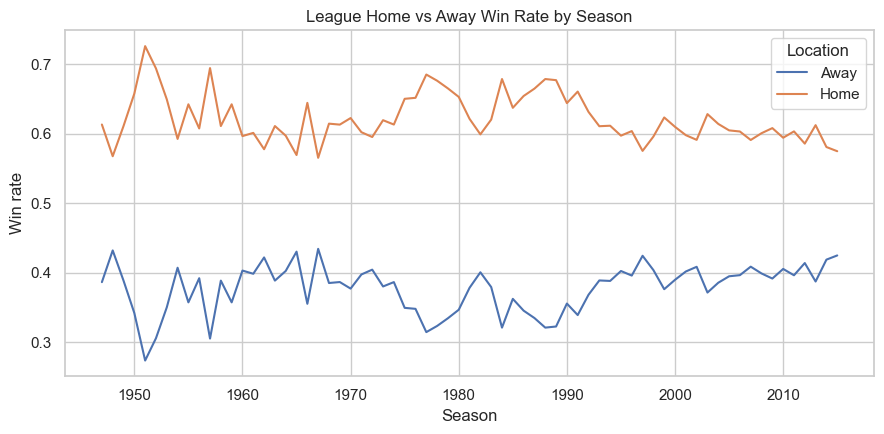

In [14]:
#League Home vs Away win rate by season 
trend = (nba.groupby(['year_id','game_location'])['win']
              .mean()
              .reset_index())

plt.figure(figsize=(9,4.5))
sns.lineplot(data=trend, x='year_id', y='win', hue='game_location', estimator=None)
plt.title('League Home vs Away Win Rate by Season')
plt.xlabel('Season'); plt.ylabel('Win rate')
plt.legend(title='Location', labels=['Away','Home'] if set(trend['game_location'])=={'A','H'} else None)
plt.tight_layout(); plt.show()


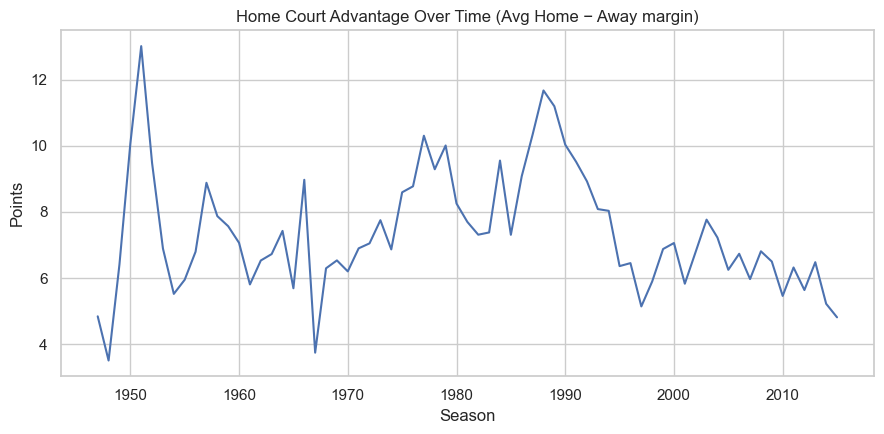

In [15]:
home_m = (nba[nba['game_location']=='H']
          .groupby('year_id')['score_diff'].mean().rename('home_margin'))
away_m = (nba[nba['game_location']=='A']
          .groupby('year_id')['score_diff'].mean().rename('away_margin'))
adv = pd.concat([home_m, away_m], axis=1).dropna()
adv['hca'] = adv['home_margin'] - adv['away_margin']
adv = adv.reset_index()

plt.figure(figsize=(9,4.5))
sns.lineplot(data=adv, x='year_id', y='hca')
plt.title('Home Court Advantage Over Time (Avg Home − Away margin)')
plt.xlabel('Season'); plt.ylabel('Points')
plt.tight_layout(); plt.show()

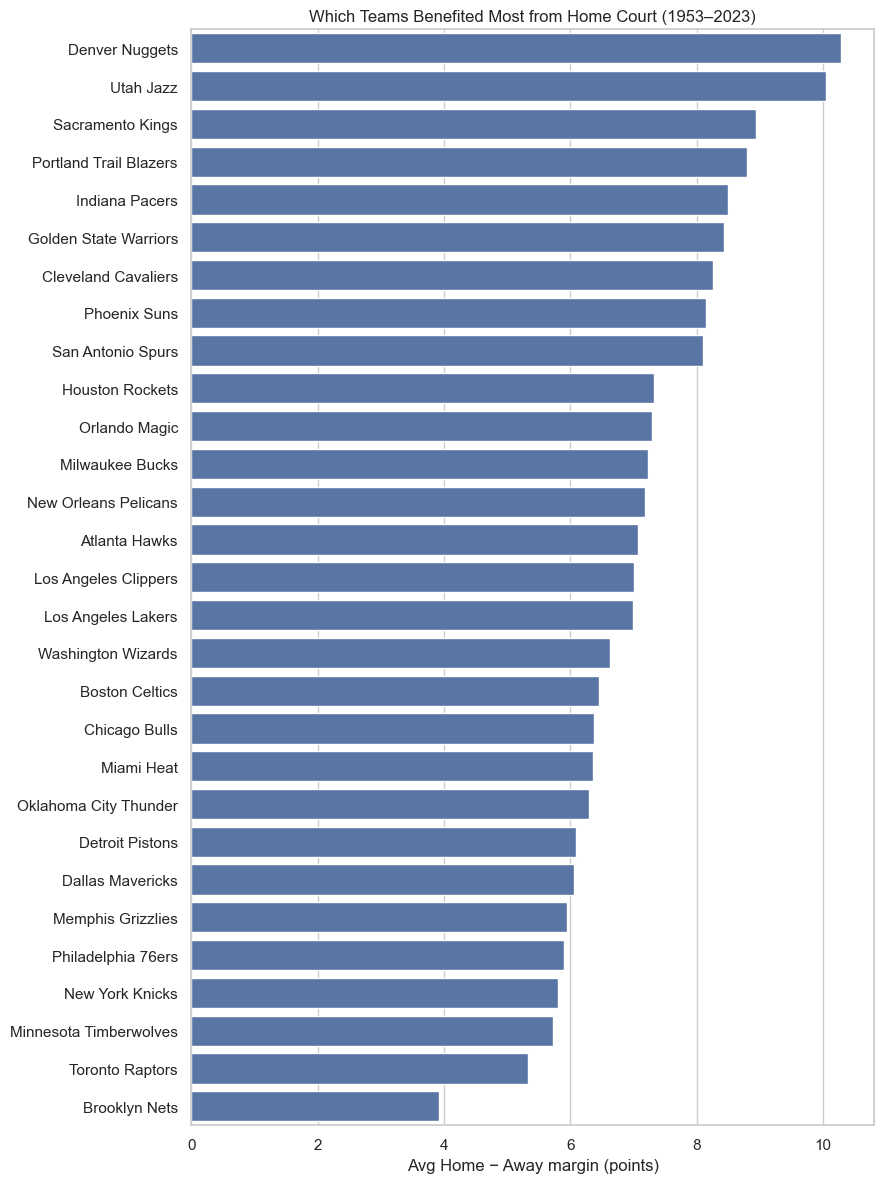

In [24]:
#Team rankings — historical and modern (bar charts)
def home_advantage_index(df):
    h = df[df['game_location']=='H'].groupby('team_id')['score_diff'].mean().rename('home_margin')
    a = df[df['game_location']=='A'].groupby('team_id')['score_diff'].mean().rename('away_margin')
    out = pd.concat([h,a], axis=1).dropna()
    out['home_advantage_index'] = out['home_margin'] - out['away_margin']
    return out.reset_index()

# Historical window
hist = nba[nba['year_id'].between(1953, 2023)]
h_hist = home_advantage_index(hist).merge(team_map[['team_id','modern_team']], on='team_id', how='left')
h_hist = h_hist.sort_values('home_advantage_index', ascending=False)

plt.figure(figsize=(9,12))
sns.barplot(data=h_hist, y='modern_team', x='home_advantage_index')
plt.title('Which Teams Benefited Most from Home Court (1953–2023)')
plt.xlabel('Avg Home − Away margin (points)'); plt.ylabel('')
plt.tight_layout(); plt.show()


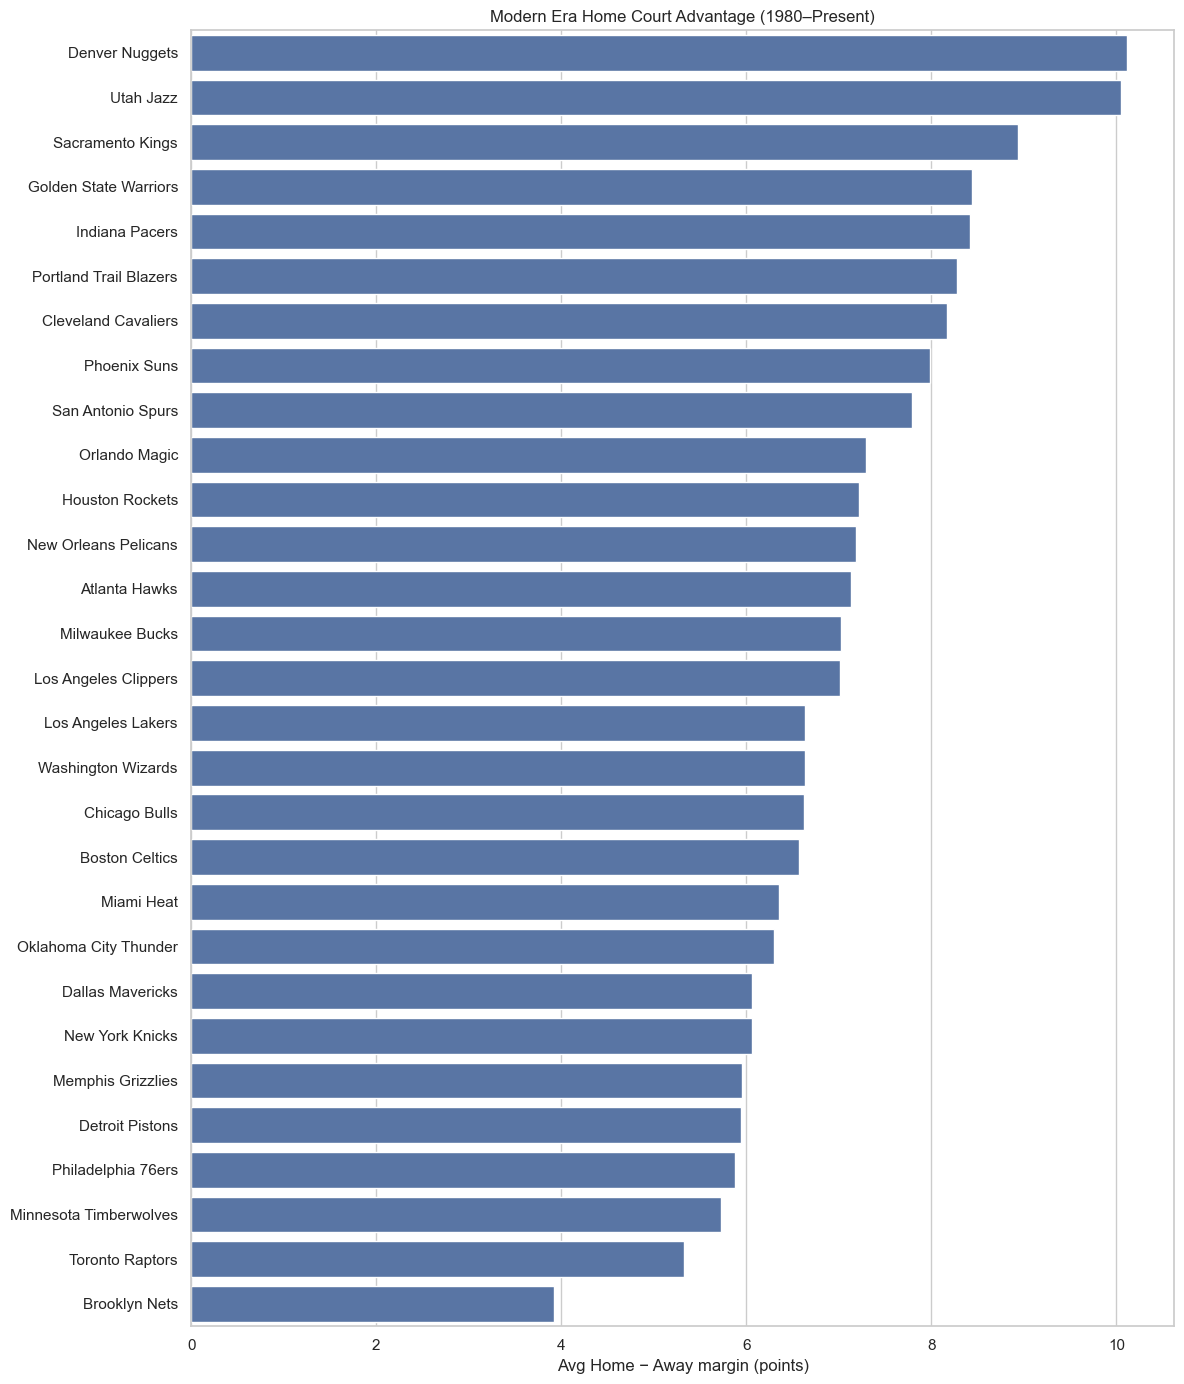

In [23]:
# Modern window (choose your cutoff)
modern = nba[nba['year_id']>=1980]
h_mod = home_advantage_index(modern).merge(team_map[['team_id','modern_team']], on='team_id', how='left')
h_mod = h_mod.sort_values('home_advantage_index', ascending=False)

plt.figure(figsize=(12,14))
sns.barplot(data=h_mod, y='modern_team', x='home_advantage_index')
plt.title('Modern Era Home Court Advantage (1980–Present)')
plt.xlabel('Avg Home − Away margin (points)'); plt.ylabel('')
plt.tight_layout(); plt.show()

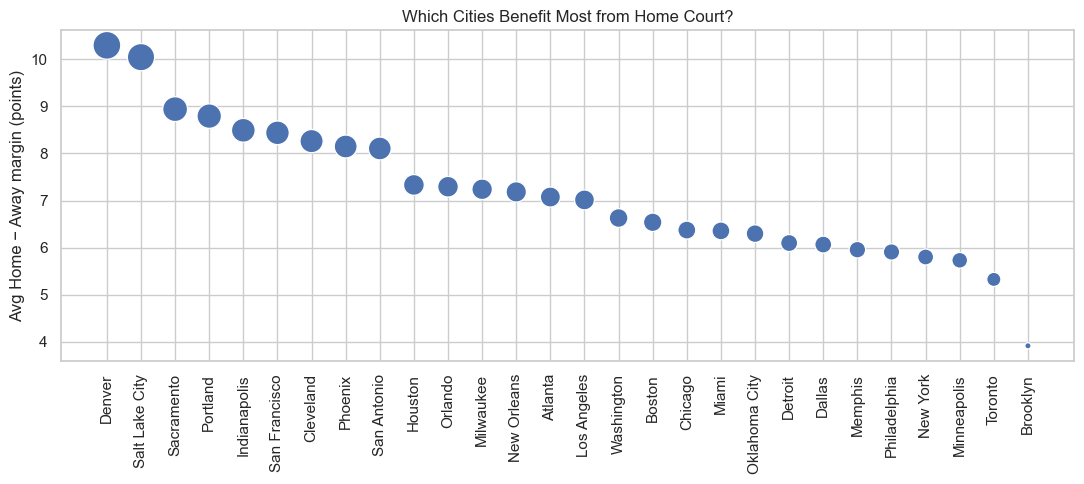

In [18]:
#Which cities benefited the most?
# Compute city-level HCA
home_city = (nba[nba['game_location']=='H']
             .merge(team_map[['team_id','city','state']], on='team_id', how='left')
             .groupby('city')['score_diff'].mean().rename('home_margin'))
away_city = (nba[nba['game_location']=='A']
             .merge(team_map[['team_id','city','state']], on='team_id', how='left')
             .groupby('city')['score_diff'].mean().rename('away_margin'))
city_adv = pd.concat([home_city, away_city], axis=1).dropna()
city_adv['home_advantage_index'] = city_adv['home_margin'] - city_adv['away_margin']
city_adv = city_adv.reset_index().dropna(subset=['city'])

# Plot
city_adv = city_adv.sort_values('home_advantage_index', ascending=False)
plt.figure(figsize=(11,5))
sizes = (city_adv['home_advantage_index'] - city_adv['home_advantage_index'].min() + 0.1) * 150
sns.scatterplot(x=np.arange(len(city_adv)),
                y='home_advantage_index',
                size=sizes, sizes=(20, 400),
                data=city_adv, legend=False)
plt.xticks(ticks=np.arange(len(city_adv)), labels=city_adv['city'], rotation=90)
plt.ylabel('Avg Home − Away margin (points)'); plt.xlabel('')
plt.title('Which Cities Benefit Most from Home Court?')
plt.tight_layout(); plt.show()

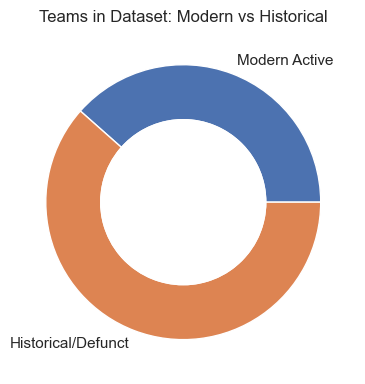

In [20]:
#Donut
modern_set = set(nba.loc[nba['year_id']>=1980, 'team_id'].unique())
all_set = set(nba['team_id'].unique())
historical_only = all_set - modern_set

sizes = [len(modern_set), len(historical_only)]
labels = ['Modern Active', 'Historical/Defunct']

fig, ax = plt.subplots(figsize=(4,4))
wedges, _ = ax.pie(sizes, labels=labels, wedgeprops=dict(width=0.4))
centre = plt.Circle((0,0), 0.6, fc='white'); ax.add_artist(centre)
plt.title('Teams in Dataset: Modern vs Historical'); plt.tight_layout(); plt.show()

In [21]:
# Is Home Court Advantage Up or Down? 
import statsmodels.api as sm

df = adv[['year_id','hca']].dropna()
X = sm.add_constant(df['year_id'])
y = df['hca']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    hca   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9656
Date:                Tue, 04 Nov 2025   Prob (F-statistic):              0.329
Time:                        23:00:16   Log-Likelihood:                -138.20
No. Observations:                  69   AIC:                             280.4
Df Residuals:                      67   BIC:                             284.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.7953     21.792      1.321      0.1